In [1]:
from collections import deque
from collections.abc import Iterable
from io import BytesIO
from typing import Optional

from PIL import Image

def parse_map(lines: Iterable[str]) -> list[list[Optional[int]]]:
    size = -1
    rows: list[list[Optional[int]]] = []
    for (y, line) in enumerate(lines):
        if y == 0:
            size = len(line)
            assert (size >= 3) and (size % 2 == 1)
            midpoint = size // 2
        else:
            assert (y < size) and (len(line) == size)
        row: list[Optional[int]] = []
        for (x, char) in enumerate(line):
            if y == midpoint == x:
                assert char == 'S'
                row.append(-1)
            elif char == '#':
                row.append(None)
            else:
                assert char == '.'
                row.append(-1)
        rows.append(row)
    assert y + 1 == size
    return rows

def expand_map(rows: list[list[Optional[int]]], factor: int) -> None:
    assert (factor >= 3) and (factor % 2 == 1)
    original_size = len(rows)
    for row in rows:
        row.extend(row * (factor - 1))
    for _ in range(factor - 1):
        for i in range(original_size):
            rows.append(rows[i].copy())

def fill_map(rows: list[list[Optional[int]]], steps: int) -> None:
    assert steps >= 1
    midpoint = len(rows) // 2
    max_dim = len(rows) - 1
    rows[midpoint][midpoint] = 0
    to_visit = deque([(midpoint, midpoint)])
    while to_visit:
        (x, y) = to_visit.popleft()
        step = rows[y][x]
        assert step is not None
        next_step = step + 1
        if next_step > steps:
            continue
        if (y > 0) and (rows[y - 1][x] == -1):
            rows[y - 1][x] = next_step
            to_visit.append((x, y - 1))
        if (y < max_dim) and (rows[y + 1][x] == -1):
            rows[y + 1][x] = next_step
            to_visit.append((x, y + 1))
        if (x > 0) and (rows[y][x - 1] == -1):
            rows[y][x - 1] = next_step
            to_visit.append((x - 1, y))
        if (x < max_dim) and (rows[y][x + 1] == -1):
            rows[y][x + 1] = next_step
            to_visit.append((x + 1, y))

def count_reachable_garden_plots(rows: list[list[Optional[int]]], steps: int) -> int:
    remainder = steps % 2
    return sum(
        1
        for row in rows
        for tile in row
        if (tile is not None) and (0 <= tile <= steps) and (tile % 2 == remainder)
    )

def visualise_map(rows: list[list[Optional[int]]], steps: int) -> Image.Image:
    assert 1 <= steps <= 255
    boost = 255 - steps
    size = len(rows)
    buffer = BytesIO()
    for row in rows:
        for tile in row:
            if tile is None:
                # blue for rock
                buffer.write(bytes([0, 0, 255]))
            elif 1 <= tile <= steps:
                # green gradient for visited garden plot
                buffer.write(bytes([0, boost + tile, 0]))
            elif tile == 0:
                # magenta for starting garden plot
                buffer.write(bytes([255, 0, 255]))
            elif tile == -1:
                # black for unvisited garden plot
                buffer.write(bytes([0, 0, 0]))
            else:
                # red for unexpected tile value
                buffer.write(bytes([255, 0, 0]))
    image = Image.frombytes(mode='RGB', size=(size, size), data=buffer.getvalue())
    return image

def visualise(lines: Iterable[str], factor: int, steps: int, expected_reachable_garden_plots: Optional[int] = None) -> Image.Image:
    map_ = parse_map(lines)
    if factor != 1:
        expand_map(map_, factor)
    fill_map(map_, steps)
    if expected_reachable_garden_plots is not None:
        assert count_reachable_garden_plots(map_, steps) == expected_reachable_garden_plots
    return visualise_map(map_, steps)

In [2]:
example_input_lines = [
    '...........',
    '.....###.#.',
    '.###.##..#.',
    '..#.#...#..',
    '....#.#....',
    '.##..S####.',
    '.##..#...#.',
    '.......##..',
    '.##.#.####.',
    '.##..##.##.',
    '...........',
]
with open('input.txt', mode='rt') as input_file:
    input_lines = [line.rstrip('\n') for line in input_file]

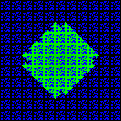

In [3]:
visualise(example_input_lines, 11, 43)

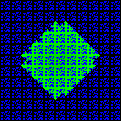

In [4]:
visualise(example_input_lines, 11, 44)

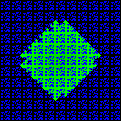

In [5]:
visualise(example_input_lines, 11, 45)

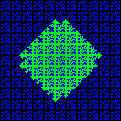

In [6]:
visualise(example_input_lines, 11, 46)

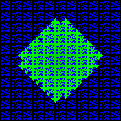

In [7]:
visualise(example_input_lines, 11, 47)

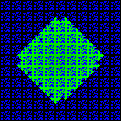

In [8]:
visualise(example_input_lines, 11, 48)

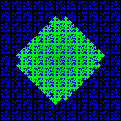

In [9]:
visualise(example_input_lines, 11, 49)

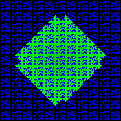

In [10]:
visualise(example_input_lines, 11, 50, 1594)

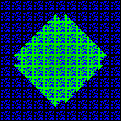

In [11]:
visualise(example_input_lines, 11, 51)

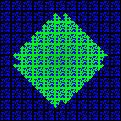

In [12]:
visualise(example_input_lines, 11, 52)

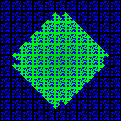

In [13]:
visualise(example_input_lines, 11, 53)

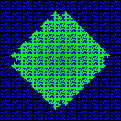

In [14]:
visualise(example_input_lines, 11, 54)

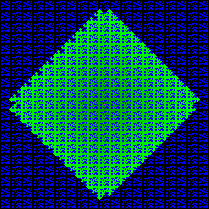

In [15]:
visualise(example_input_lines, 19, 100, 6536)

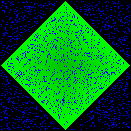

In [16]:
visualise(input_lines, 1, 64, 3758)

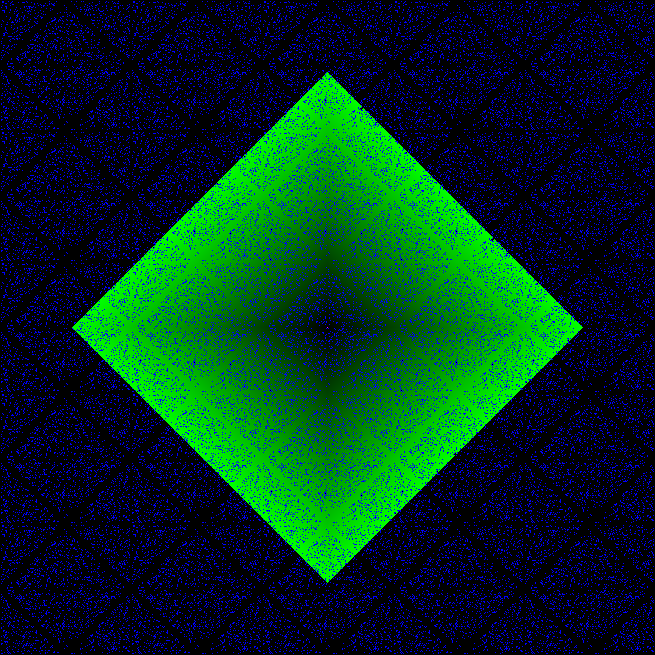

In [17]:
visualise(input_lines, 5, 255)